# BMEB W4020: Circuits in the Brain 2025 Fall Project \#2

*Author:* Shashwat Shukla <shashwat.shukla@columbia.edu>

Based on past work by Tingkai Liu and Cong Han

*Copyright 2025* Bionet Lab

Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).
Make sure you fill up your name and collaborators below:

### Your names and UNI here

NAME = "Alexander Speer"
UNI  = "aes2376"

COLLABORATORS = "Andre Perez - avp2141@columbia.edu"



In this project, you will encode, decode and identify a biophysical neuron consisting of a dendritic tree, a soma, and a conductance-based axon hillock. The axon hillock is modelled as ON-OFF neurons in AER configuration.
<center><img src="figures/fig1.png" width=600 ></center>
<center><b>Figure 1</b>: Neuron modeled as [Filter]-[Encoder] Cascade.</center>

<center><img src="figures/fig2.png" width=600 ></center>
<center><b>Figure 2</b>: Dendritic processing: Two linear filters. Soma: ON-OFF encoder in AER configuration.</center>

## Problem 1

In this part, you will encode and decode a randomly generated input stimulus using the given neuron model when the dendritic filter is known to you. In particular, the dendritic filter is defined as $h_1(t) = 300 \cdot e^{-300\cdot t}$ and $h_2(t) = 200 \cdot e^{-200\cdot t}$. We further let $u_1 = u_2 = u$.

### Questions:

1. (20 points) Encode a randomly generated signal $u(t)$ of bandwidth $50$ Hertz using the given neuron model, and plot the time-course of the membrane voltage of the soma. Also detect and label the spikes from the ON and OFF channels on the same plot.  use the convolution distributive property for Q1 where (u * h1) + (u * h2) = u * (h1 + h2) when encoding the spike.
2. (20 points) Use the detected spikes to decode the input signal $u(t)$. Plot the time-courses of the decoded and original input signal on the same plot to illustrate the quality of recovery. Also plot the time-course of the corresponding SNR between the signals. You cannot decode both u1 and u2 if they are different (linearly independent over time) by simulating a single experiment, as you run into an instance of blind source separation. This is why we assume that u1=u2 so that the problem is not under-constrained.

The most convenient way to code up the decoder is to indeed concatenate and sort the ON and OFF spikes together by representing them as signed spikes, so that you only have one G matrix and one q vector. The decoding algorithm then explicitly makes use of the sign of each spike; c.f Section "AER Neuron with Thresholding and Feedback" from the Chapter 8 python notebook.

In [19]:
#Mount the drive and then point them to the right folder
from google.colab import drive
drive.mount('/content/drive')

import sys, importlib

# Make sure you're not loading a stale/local copy of compneuro
if 'compneuro' in sys.modules:
    del sys.modules['compneuro']
#the right path we should be using project 2
sys.path.insert(0, "/content/drive/MyDrive/CCircuits/project2")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

In [21]:
def signal_generator(t, samples, sample_times, omega):
    signal = np.zeros_like(t)
    for s, st in zip(samples, sample_times):
        signal += omega / np.pi * s * np.sinc(omega / np.pi * (t - st))
    return signal

In [22]:
# just gens the input signal to the dendrite
f = 50  # Hz
omega = 2 * np.pi * f
T = 2 * np.pi / omega
omega_pi = omega / np.pi
dt = 1e-6  # in seconds
t = np.arange(0, 0.2, dt)

# this is going to be a random bandlimited stimulus or u(t)

# the Nyquist sampling
T_nyq = np.pi / omega

# the number of the Nyquist samples
K = int(t[-1] / T_nyq)

# diff sample locations and also random amplitudes
sample_times = np.arange(K) * T_nyq
samples = np.random.randn(K)

# gen. the bandlimited signal
u = signal_generator(t, samples, sample_times, omega)

# and then normalize to the unit amplitude
u = u / np.max(np.abs(u))


In [23]:
# the dendritic filters
t_filt = np.arange(0, 0.1, dt)

h1 = 300 * np.exp(-300 * t_filt)
h2 = 200 * np.exp(-200 * t_filt)

# the effective dendritic filter that use distributive property
h = h1 + h2

In [24]:
# just compute the input signal to the axon hillock
v = np.convolve(u, h, mode="full") * dt
v = v[:len(u)]


In [25]:
# now time to encode the input signal

delta = 0.2

V = np.zeros_like(t) # membrane voltage trace
trigger = 0.0  # the last value of v at a spike time
tk = []  # the signed spike time

for i in range(1, len(t)):
    # AER membrane potenttial
    V[i] = v[i] - trigger

    # loo for ON or OFF spikes
    if V[i] >= delta:
        # and the ON spike
        tk.append(t[i]) # store as +t
        trigger = v[i] # should just reset trigger to current input
    elif V[i] <= -delta:
        # the OFF spike
        tk.append(-t[i]) # store as -t yay
        trigger = v[i] # reset the trigger to current input

tk = np.array(tk)

# just includde in order to separate the ON and OFF spike times for plotting
tk_on = tk[tk > 0]
tk_off = -tk[tk < 0]


In [26]:
# should compute the padded signals

# Maximum absolute spike time
t_max_spike = np.max(np.abs(tk))

# Extend time axis so sinc kernels are well supported
t_pad_end = max(t[-1], t_max_spike)
t_pad = np.arange(0, t_pad_end + dt, dt)

# Pad original signal u(t)
u_pad = np.zeros_like(t_pad)
u_pad[:len(u)] = u

# will be used to pad soma input v(t)
v_pad = np.zeros_like(t_pad)
v_pad[:len(v)] = v

In [27]:
# this block will estimate the G matrix

tk_abs = np.abs(tk) #use absolute spike times for the kernel centers

temp = np.tile(tk_abs, (len(tk_abs), 1)).T
G = omega / np.pi * np.sinc(omega / np.pi * (temp - temp.T))


In [28]:
# Estimate q vector
sgn = np.sign(tk) #going to be +1 for ON spikes, -1 for OFF spikes
q = np.cumsum(sgn) * delta


In [29]:
# this block will estaimte the coefficients and then reconstruct the input signal to the dendrite
c_rec = np.linalg.pinv(G, rcond=1e-4) @ q
v_rec = signal_generator(t, c_rec, tk_abs, omega)


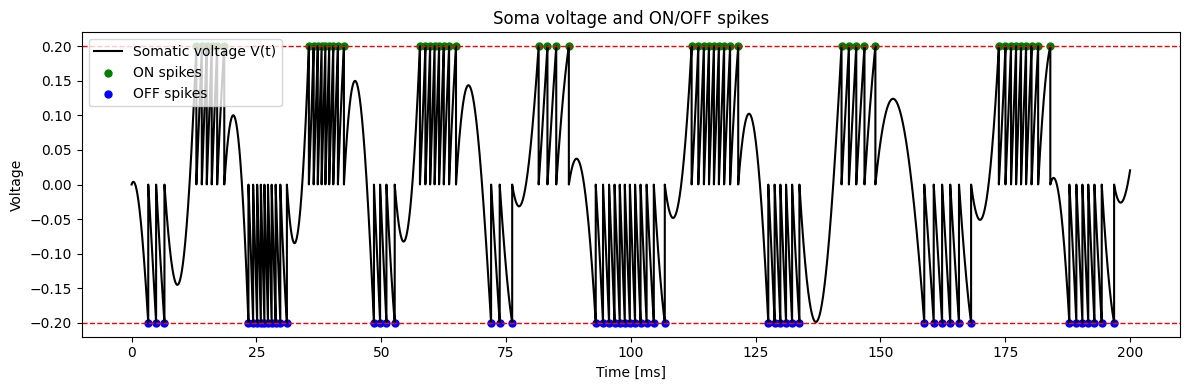

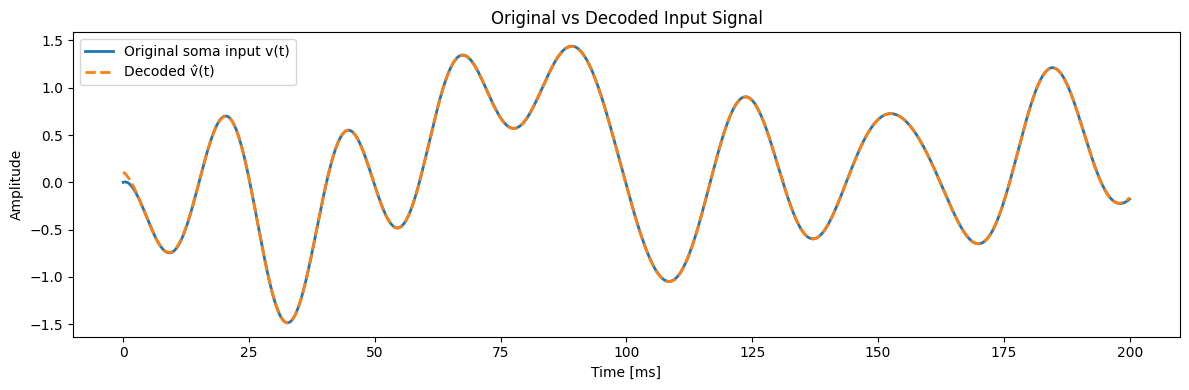

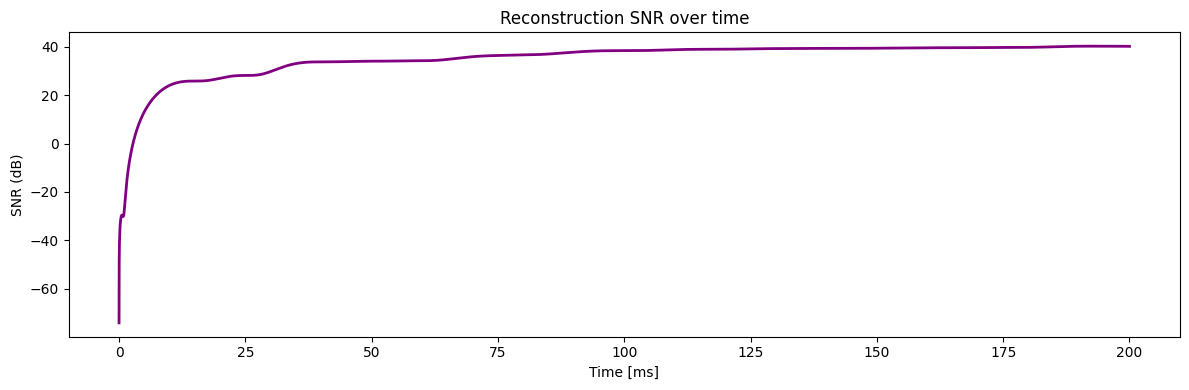

In [30]:
# plotting

# soma voltage
plt.figure(figsize=(12, 4))
plt.plot(t * 1e3, V, label="Somatic voltage V(t)", color="black")

plt.axhline(delta, color="red", linestyle="--", linewidth=1)
plt.axhline(-delta, color="red", linestyle="--", linewidth=1)

# ON spikes
plt.scatter(tk_on * 1e3,
            np.ones_like(tk_on) * delta,
            color="green", s=25, label="ON spikes")

#OFF spikes
plt.scatter(tk_off * 1e3,
            -np.ones_like(tk_off) * delta,
            color="blue", s=25, label="OFF spikes")

plt.xlabel("Time [ms]")
plt.ylabel("Voltage")
plt.title("Soma voltage and ON/OFF spikes")
plt.legend()
plt.tight_layout()
plt.show()


# the og versus the decoded signal
plt.figure(figsize=(12, 4))
plt.plot(t * 1e3, v, label="Original soma input v(t)", linewidth=2)
plt.plot(t * 1e3, v_rec, label="Decoded v̂(t)", linewidth=2, linestyle="--")

plt.xlabel("Time [ms]")
plt.ylabel("Amplitude")
plt.title("Original vs Decoded Input Signal")
plt.legend()
plt.tight_layout()
plt.show()


# and the time course SNR plot
num = np.cumsum(v**2)
den = np.cumsum((v - v_rec)**2) + 1e-12
snr_t = 10 * np.log10(num / den)

plt.figure(figsize=(12, 4))
plt.plot(t * 1e3, snr_t, color="purple", linewidth=2)
plt.xlabel("Time [ms]")
plt.ylabel("SNR (dB)")
plt.title("Reconstruction SNR over time")
plt.tight_layout()
plt.show()


## Problem 2

You are each given a black-box instance of the neuron described above (with name `neuron_uni.py`) that takes a time vector $t$ and an input signal $u$ as input arguments.
- In "Dendrite" mode, the model first feeds $u$ to the dendritic tree, then passes the output of the dendritic tree to the axon hillock, and finally returns the spike train $\sum_k \delta(t-t_k)$ generated by the axon-hillock. In this case $u$ should be a 2D array with $u[0]=u_1, u[1]=u_2$.
- In "Axon" mode, $u$ is passed directly to the axon-hillock. In this case $u$ should be a 1D array of the same shape as $t$.

The model given to you in `model_uni.py` can be used by doing the following:
```python
>>> from model_uni import model
>>> tk1 = model(t, np.array([u1, u2]), "Dendrite") # inject into dendritic tree
>>> tk2 = model(t, v, "Axon") # inject into axon-hillock
```

### Questions:
Your task is to identify the circuit.
1. (20 points) We will start with identifying the AER unit. Inject the axon-hillock with appropriately chosen currents to verify that the firing threshold $\delta = 5e^{-5}$. Briefly explain your methodology. refer to "8.1.3. Time Encoding with Silicon Neurons" from the Jupyter book and the corresponding python notebook section "AER Neuron with Thresholding and Feedback".
2. (40 points) Identify the two filters $(h^1(t),h^2(t))$ on $t\in [0,0.5]$[s] by generating random non-zero bandlimited input signals ${\bf u} = (u_1, u_2)$ in the _trignometric polynomial_ space. Choose any other parameters for your experiments as appropriate.
    1. For a range of bandwidths $\Omega^i, i=1,2,\ldots$, identify the filters $\hat{h}_{1,i}, \hat{h}_{2,i}$ by using the input with corresponding bandwidth. Calculate the mean square error $\epsilon_i = MSE(\hat{h}_{1,i-1}, \hat{h}_{1,i}) + MSE(\hat{h}_{2,i-1}, \hat{h}_{2,i})$, where $\hat{h}_{1,0}=\hat{h}_{2,0}=0$.
    2. Plot $\epsilon_i$ v.s. $\Omega_i$. What do you find? Can you identify the effective bandwidth of the unknown dendritic processing filters?
    note: To verify that your identification algorithm works, you can test it on a white-box version of the circuit where you generate the dendritic filters yourself and then verify that your algorithm identifies them correctly. You can then use this now verifiably correct identification algorithm on the black-box model assigned to you.

to generate amplitudes M for the first part where we make the trigonometric stimuli for the function to usefor the first part where we make the trigonometric stimuli for the function to use:

def stimulus(t, omega, ck, normalize=True):
    """
    Generate a stimulus as a sum of sinc functions
    
    Arguments:
        t: 1D array of the time period for the resultant stimulus
        omega: scalar frequency of the sinc basis functions
        s: 1D array of amplitudes for the sinc functions
    
    Returns:
        1D array containing the stimulus
    """
    out = np.zeros_like(t)
    T = np.pi / omega  # sampling interval at nyquist rate
    sk = np.arange(len(ck)) * T  # uniform sample at nyquist rate
    out = ck @ sinc_basis(t, sk, omega)
    if normalize:
        return out / np.max(np.abs(out))
    return out

__Bonus__. (12.5 points) In HW5-Q2, you worked out the theory to estimate the filters $h_1, h_2$ _separately_, which you can use in Part 2 of this question. For this bonus question, write down the theory and simulate your results for _jointly_ estimating $h_1, h_2$ using two sets of randomly generated stimuli ${\bf u^1}$ and ${\bf u^2}$ wherein all the signals $u_1^1, u_2^1, u_1^2, u_2^2$ are _non-zero_.  


In [31]:
import importlib.util
import sys

model_file = "/content/drive/MyDrive/CCircuits/project2/model_aes2376.py"

spec = importlib.util.spec_from_file_location("model_aes2376", model_file)
model_aes2376 = importlib.util.module_from_spec(spec)
sys.modules["model_aes2376"] = model_aes2376
spec.loader.exec_module(model_aes2376)

print("Loaded from:", model_aes2376.__file__)


Loaded from: /content/drive/MyDrive/CCircuits/project2/model_aes2376.py


# **Problem 1**

(20 points) We will start with identifying the AER unit. Inject the axon-hillock with appropriately chosen currents to verify that the firing threshold  𝛿=5𝑒−5 . Briefly explain your methodology. refer to "8.1.3. Time Encoding with Silicon Neurons" from the Jupyter book and the corresponding python notebook section "AER Neuron with Thresholding and Feedback".

Loaded from: /content/drive/MyDrive/CCircuits/project2/model_aes2376.py

Ramp test:
  # spikes: 19
  delta_est (median diff of u at spikes): 5.000000000000002e-05
  delta_true: 5e-05
  relative error: 4.0657581468206416e-16

Step sanity check:
  step amplitude = 0.9*delta -> # spikes: 0
  step amplitude = 1.1*delta -> # spikes: 1


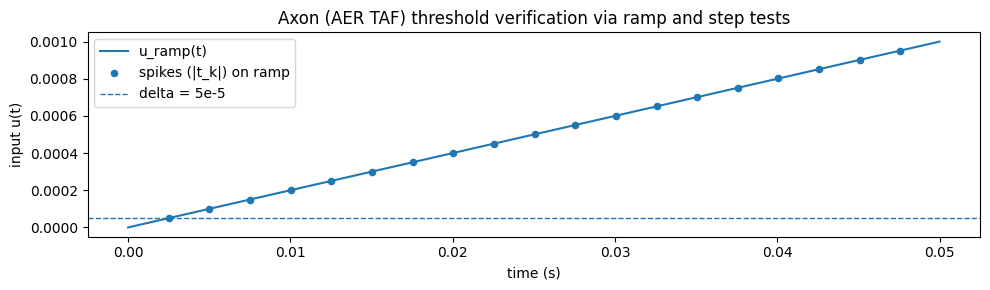

In [32]:
#imports
import importlib.util, sys
import numpy as np
import matplotlib.pyplot as plt

#  very complicated way of just loadding the black-box model
model_file = "/content/drive/MyDrive/CCircuits/project2/model_aes2376.py"
spec = importlib.util.spec_from_file_location("model_aes2376", model_file)
model_aes2376 = importlib.util.module_from_spec(spec)
sys.modules["model_aes2376"] = model_aes2376
spec.loader.exec_module(model_aes2376)
print("Loaded from:", model_aes2376.__file__)

#ramp injection
dt = 1e-5
T_end = 0.05  #s
t = np.arange(0.0, T_end, dt)

delta_true = 5e-5
slope = 2e-2  # the units/s
u_ramp = slope * t

tk = model_aes2376.model(t, u_ramp, "Axon")  # this is the signed spike times, per AER ON/OFF
tk = np.array(tk, dtype=float)

# Lets convert the returned spike times now into indices in the t, then sample u at spikes
tk_abs = np.abs(tk)
idx_spk = np.clip(np.round(tk_abs / dt).astype(int), 0, len(t) - 1)
u_spk = u_ramp[idx_spk]

# For a monotone ramp, the consecutive spike amplitudes are going to be differing by ~delta
if len(u_spk) >= 2:
    du = np.diff(u_spk)
    delta_est = float(np.median(du))
    rel_err = abs(delta_est - delta_true) / delta_true
else:
    delta_est = np.nan
    rel_err = np.nan

print("\nRamp test:")
print("  # spikes:", len(tk))
print("  delta_est (median diff of u at spikes):", delta_est)
print("  delta_true:", delta_true)
print("  relative error:", rel_err)

#sanity check
u_step_low  = np.ones_like(t) * (0.9 * delta_true)
u_step_high = np.ones_like(t) * (1.1 * delta_true)

tk_low  = np.array(model_aes2376.model(t, u_step_low,  "Axon"), dtype=float)
tk_high = np.array(model_aes2376.model(t, u_step_high, "Axon"), dtype=float)

print("\nStep sanity check:")
print("  step amplitude = 0.9*delta -> # spikes:", len(tk_low))
print("  step amplitude = 1.1*delta -> # spikes:", len(tk_high))

# the plot for the ramp input + spike markers
plt.figure(figsize=(10, 3))
plt.plot(t, u_ramp, linewidth=1.5, label="u_ramp(t)")
if len(tk) > 0:
    plt.scatter(tk_abs, u_spk, s=20, label="spikes (|t_k|) on ramp")
plt.axhline(delta_true, linestyle="--", linewidth=1.0, label="delta = 5e-5")
plt.xlabel("time (s)")
plt.ylabel("input u(t)")
plt.title("Axon (AER TAF) threshold verification via ramp and step tests")
plt.legend()
plt.tight_layout()
plt.show()


We can see that the ramp input plot shows that all of the spikes occur at regular and equal increments of the input amplitude, lasting along the linear ramp.  We can observe that in our AER TAF neuron, this behavior indicates that each spike is generated when the input increases by exactly the firing threshold relative to the last trigger. To this end, the constant vertical spacing between the successive spike points matches the dashed line at

$$
\delta = 5 \times 10^{-5},
$$

This essentially confirms the threshold value in the problem description.

Additionally, we can see that the step input provides an independent check, meaning that a constant input slightly below the $\delta$ does not manage to produce any spikes, while a constant input slightly above $\delta$ produces exactly one spike, which is what should be expected from the AER thresholding rule with the trigger reset. Together, we can say that these observations objectively verify that the axon-hillock firing threshold is

$$
\delta = 5 \times 10^{-5}.
$$




# **Problem 2**

2. (40 points) Identify the two filters $(h^1(t),h^2(t))$ on $t\in [0,0.5]$[s] by generating random non-zero bandlimited input signals ${\bf u} = (u_1, u_2)$ in the _trignometric polynomial_ space. Choose any other parameters for your experiments as appropriate.
    1. For a range of bandwidths $\Omega^i, i=1,2,\ldots$, identify the filters $\hat{h}_{1,i}, \hat{h}_{2,i}$ by using the input with corresponding bandwidth. Calculate the mean square error $\epsilon_i = MSE(\hat{h}_{1,i-1}, \hat{h}_{1,i}) + MSE(\hat{h}_{2,i-1}, \hat{h}_{2,i})$, where $\hat{h}_{1,0}=\hat{h}_{2,0}=0$.
    2. Plot $\epsilon_i$ v.s. $\Omega_i$. What do you find? Can you identify the effective bandwidth of the unknown dendritic processing filters?
    note: To verify that your identification algorithm works, you can test it on a white-box version of the circuit where you generate the dendritic filters yourself and then verify that your algorithm identifies them correctly. You can then use this now verifiably correct identification algorithm on the black-box model assigned to you.

Lets first test our logic with a white box neuron on the aforementioned AER ON/OFF neuron.


 WHITE-BOX SWEEP (AER ON/OFF) 
[setup] dt=1.0e-05  T=0.5  df=2.0  delta=5e-05
[setup] white-box ground truth effective bandwidth f_true_eff=50.0 Hz

[i=01] fmax=20.0 Hz | Omega=  125.66 rad/s | L=10 | unknowns/filter=21
  [h1] rows=170 rank=21/21 cond≈2.64e+00 rel_resid=4.22e-01 M=1.0e-04
  [h2] rows=168 rank=21/21 cond≈3.01e+00 rel_resid=6.20e-02 M=1.0e-04
  epsilon_i = 2.442e+01
[i=02] fmax=30.0 Hz | Omega=  188.50 rad/s | L=15 | unknowns/filter=31
  [h1] rows=260 rank=31/31 cond≈2.89e+00 rel_resid=2.28e-01 M=1.0e-04
  [h2] rows=257 rank=31/31 cond≈3.49e+00 rel_resid=2.92e-01 M=2.0e-04
  epsilon_i = 1.455e+01
[i=03] fmax=40.0 Hz | Omega=  251.33 rad/s | L=20 | unknowns/filter=41
  [h1] rows=340 rank=41/41 cond≈2.98e+00 rel_resid=3.31e-01 M=1.0e-04
  [h2] rows=343 rank=41/41 cond≈3.14e+00 rel_resid=1.11e-01 M=2.0e-04
  epsilon_i = 1.014e+01
[i=04] fmax=50.0 Hz | Omega=  314.16 rad/s | L=25 | unknowns/filter=51
  [h1] rows=417 rank=51/51 cond≈3.43e+00 rel_resid=2.35e-01 M=1.0e-04
  [h

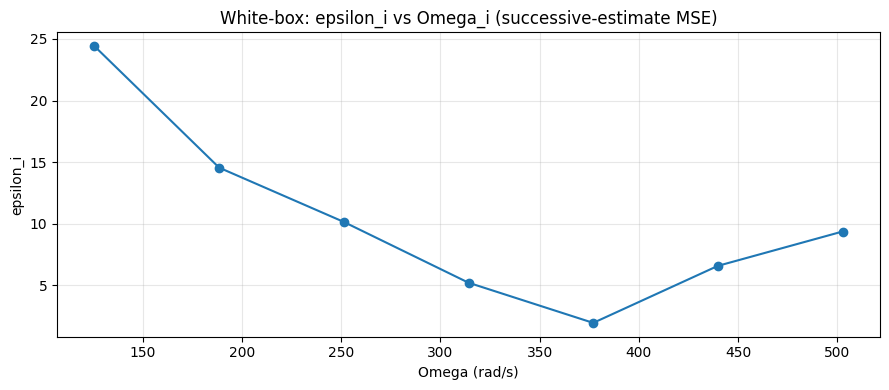

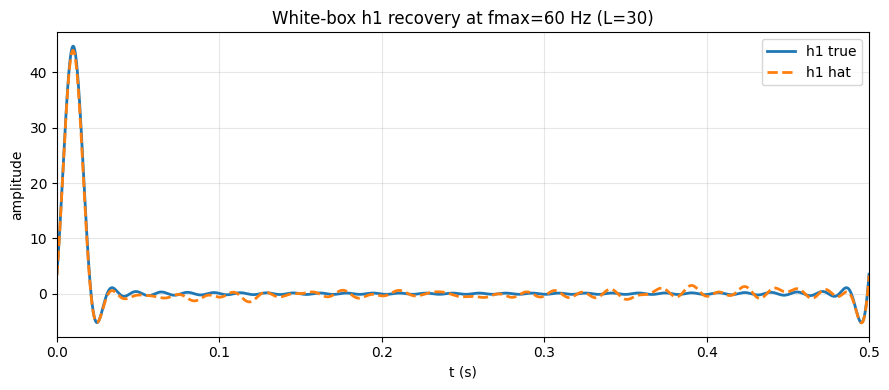

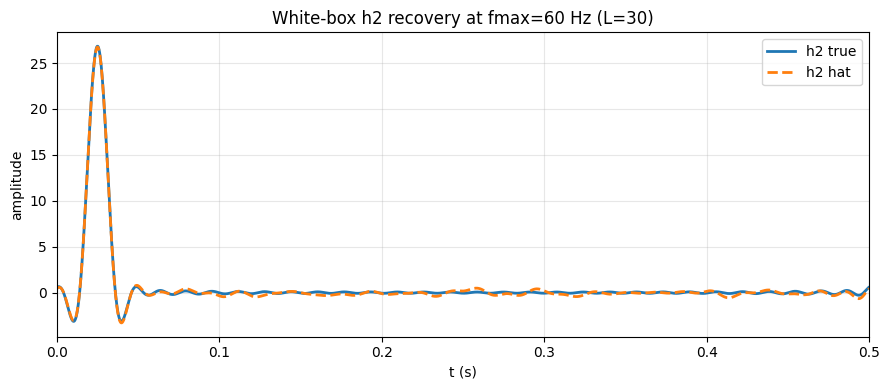


Plateau criterion:
  tail median epsilon ~ 6.576e+00, threshold = 7.891e+00
  estimated effective bandwidth: f_eff ~ 50 Hz (Omega_eff ~ 314.16 rad/s)


In [33]:
# this is the White-box dendrite (known h1,h2), importantly this uses the same AER ON/OFF encoder as Problem 1
import numpy as np
import matplotlib.pyplot as plt

# these should match the given project 2 conventions thus far.
dt = 1e-5                 #s
df = 2.0                  # Hz
T = 1.0 / df              # also seconds
t = np.arange(0.0, T, dt) # [0, T)
delta = 5e-5              # AER threshold from 2.1 just verified

rng_global = np.random.default_rng(0)

#however now we have trig identities:
#u(t) = sum_{l=-L}^L u_l * exp(j*2π*l*df*t).
def random_trig_signal(L: int, t: np.ndarray, df: float, rng: np.random.Generator):
    """
    Returns:
      u_l: complex coefficients ordered by l=-L..L (shape (2L+1,))
      u: real signal on t (shape (Nt,))
    """
    # will build  a conjugate-symmetric spectrum for a real signal
    u_l = np.zeros(2 * L + 1, dtype=np.complex128)

    # the DC term real
    u_l[L] = rng.normal(0.0, 1.0)

    # the positive frequencies lasting from 1..L
    pos = rng.normal(0.0, 1.0, size=L) + 1j * rng.normal(0.0, 1.0, size=L)
    u_l[L + 1 :] = pos
    u_l[:L] = np.conj(pos[::-1])  # here are all of the negative freqs

    # and this should synthesize in tbe time domain
    l_grid = np.arange(-L, L + 1)
    E = np.exp(1j * 2.0 * np.pi * (l_grid[None, :] * df) * t[:, None])  # (Nt, 2L+1)
    u = np.real(E @ u_l)

    # Nnormalize
    m = np.max(np.abs(u))
    if m > 0:
        u = u / m
        u_l = u_l / m

    return u_l, u

def synth_from_coeffs(c_l: np.ndarray, t: np.ndarray, df: float):
    """c_l ordered bythe  l=-L..L"""
    L = (len(c_l) - 1) // 2
    l_grid = np.arange(-L, L + 1)
    E = np.exp(1j * 2.0 * np.pi * (l_grid[None, :] * df) * t[:, None])
    return np.real(E @ c_l)

# this is going to be the same AER ON/OFF encoder as in the project 2 problem 1
# uses the axon hillock
# will output: signed spike times tk (ON positive, OFF negative)
def aer_onoff_encode(t: np.ndarray, v: np.ndarray, delta: float):
    trigger = 0.0
    tk = []
    V = np.zeros_like(v)

    for i in range(1, len(t)):
        V[i] = v[i] - trigger
        if V[i] >= delta:
            tk.append(+t[i])
            trigger = v[i]
        elif V[i] <= -delta:
            tk.append(-t[i])
            trigger = v[i]

    return V, np.array(tk, dtype=float)

def aer_q_from_tk(tk: np.ndarray, delta: float):
    # the AER signed-spike t-transform: basically just q_k = delta * sum_{m<=k} sgn(t_m)
    return delta * np.cumsum(np.sign(tk))

#and then this is the:
# white box "unknown" dendritic filters (essentially the truth) that is defined in trig-poly domain
#and this should be that the rffective bandwidth is now controlled by spectral envelope width.
def make_true_filter_coeffs(L: int, df: float, kind: str, f_eff_hz: float):
    l = np.arange(-L, L + 1)
    # try to onvert f_eff bandwidth to the to index scale in l.
    l0 = max(1.0, f_eff_hz / df)

    # smoother evelope
    env = np.exp(- (np.abs(l) / l0) ** 4)

    # this should aAdd a small time shift amke more symmetric.
    if kind == "h1":
        tau = 0.010
        scale = 1.0
    else:
        tau = 0.025
        scale = 0.6

    phase = np.exp(-1j * 2.0 * np.pi * (l * df) * tau)

    # this si the real time-domain that requires a diff. conjugate symmetry
    h_l = scale * env * phase
    h_l[L] = np.real(h_l[L])  # DC real
    for k in range(1, L + 1):
        h_l[L - k] = np.conj(h_l[L + k])

    return h_l.astype(np.complex128)

# identifdication for just one of the channels
def estimate_filter_single_channel(
    t: np.ndarray,
    df: float,
    delta: float,
    L: int,
    h_l_true: np.ndarray, # this
    n_trials_max: int = 60,
    row_factor: float = 8.0,
    K_cap: int = 6000,
    M_try = (1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3, 1e-2),
    seed_offset: int = 0,
    rcond: float = 1e-12,
):
    """
    will return:
      a h_hat_time: estimated filter in time domain on t
      h_hat_l: estimated filter coeffs (l=-L..L)
      info: dict with diagnostics
    """
    rng = np.random.default_rng(1234 + seed_offset + 1000 * L)

    # the tragrets
    unknowns = 2 * L + 1
    target_rows = int(np.ceil(row_factor * unknowns))

    # this will collect the diff spike-equations across diff trials
    Phi_rows = []
    q_rows = []
    total_spikes = 0
    M_used = None
    trials_used = 0

    l_grid = np.arange(-L, L + 1)

    for M in M_try:
        Phi_rows = []
        q_rows = []
        total_spikes = 0
        trials_used = 0
        M_used = M

        for tr in range(n_trials_max):
            u_l, u = random_trig_signal(L, t, df, rng)
            u = M * u
            u_l = M * u_l

            # the white-box dendrite output inthe  coefficient domain:
            v = synth_from_coeffs(u_l * h_l_true, t, df)

            # AER / encode huh
            _, tk = aer_onoff_encode(t, v, delta)
            if tk.size < 2:
                continue

            # no huge memory use
            if total_spikes >= K_cap:
                break

            # q for whichever trial we;re using
            q = aer_q_from_tk(tk, delta)  # make sure that length = #spikes

            # this will build Phi block for this trial
            tk_abs = np.abs(tk)
            E = np.exp(1j * 2.0 * np.pi * (tk_abs[:, None] * (l_grid[None, :] * df)))
            Phi = (u_l[None, :] * E)  # and then this si (K,2L+1)

            # we will append, but make sure to cap the total
            if total_spikes + len(q) > K_cap:
                take = K_cap - total_spikes
                Phi_rows.append(Phi[:take])
                q_rows.append(q[:take])
                total_spikes += take
                break
            else:
                Phi_rows.append(Phi)
                q_rows.append(q)
                total_spikes += len(q)

            trials_used += 1
            if total_spikes >= target_rows:
                break

        if total_spikes >= target_rows:
            break

    if total_spikes < unknowns:
        raise RuntimeError(
            f"Not enough spikes to solve: got {total_spikes} equations for {unknowns} unknowns. "
            f"Try increasing M_try, n_trials_max, or lowering L."
        )

    Phi_all = np.vstack(Phi_rows)
    q_all = np.concatenate(q_rows)

    # this will be solving for h1
    # h1
    h_hat_l, residuals, rank, svals = np.linalg.lstsq(Phi_all, q_all, rcond=rcond)

    # then the time-domain reconstruction on the t
    h_hat_time = synth_from_coeffs(h_hat_l, t, df)

    info = {
        "L": L,
        "unknowns": unknowns,
        "target_rows": target_rows,
        "rows_used": int(Phi_all.shape[0]),
        "trials_used": int(trials_used),
        "M_used": float(M_used),
        "rank": int(rank),
        "cond_approx": float(svals[0] / svals[-1]) if len(svals) > 1 and svals[-1] > 0 else np.inf,
        "resid_norm": float(np.linalg.norm(Phi_all @ h_hat_l - q_all) / (np.linalg.norm(q_all) + 1e-15)),
    }

    return h_hat_time, h_hat_l, info

# the white box sweep
fmax_list = [20, 30, 40, 50, 60, 70, 80]   # Lets use all of these, go lower Hz
Omega_list = [2.0 * np.pi * f for f in fmax_list]

# Choose a true "effective bandwidth" for the white-box filters
f_true_eff = 50.0  # Hz could make it whatever, but hindsight know its 50

eps_list = []
h1_hat_prev = None
h2_hat_prev = None

# this will amke sure to store one representative estimate for plotting later
snapshot = {}

print("\n WHITE-BOX SWEEP (AER ON/OFF) ")
print(f"[setup] dt={dt:.1e}  T={T}  df={df}  delta={delta}")
print(f"[setup] white-box ground truth effective bandwidth f_true_eff={f_true_eff} Hz\n")

for i, fmax in enumerate(fmax_list, start=1):
    L = int(round(fmax / df))    # this is because the max harmonic is the freq = L*df = fmax
    Omega = 2.0 * np.pi * fmax

    # this is for all of these true filters in this space.
    h1_l_true = make_true_filter_coeffs(L, df, kind="h1", f_eff_hz=f_true_eff)
    h2_l_true = make_true_filter_coeffs(L, df, kind="h2", f_eff_hz=f_true_eff)

    # this will make sure to identify the h1 via excitation
    h1_hat_t, h1_hat_l, info1 = estimate_filter_single_channel(
        t=t, df=df, delta=delta, L=L, h_l_true=h1_l_true,
        seed_offset=10, rcond=1e-12,
    )

    h2_hat_t, h2_hat_l, info2 = estimate_filter_single_channel(
        t=t, df=df, delta=delta, L=L, h_l_true=h2_l_true,
        seed_offset=20, rcond=1e-12,
    )
    if h1_hat_prev is None:
        eps = np.mean(h1_hat_t**2) + np.mean(h2_hat_t**2) #since the previous is 0
    else:
        eps = np.mean((h1_hat_t - h1_hat_prev)**2) + np.mean((h2_hat_t - h2_hat_prev)**2)

    eps_list.append(eps)
    h1_hat_prev = h1_hat_t
    h2_hat_prev = h2_hat_t

    print(f"[i={i:02d}] fmax={fmax:>4.1f} Hz | Omega={Omega:>8.2f} rad/s | L={L:>2d} | unknowns/filter={2*L+1}")
    print(f"  [h1] rows={info1['rows_used']} rank={info1['rank']}/{info1['unknowns']} cond≈{info1['cond_approx']:.2e} rel_resid={info1['resid_norm']:.2e} M={info1['M_used']:.1e}")
    print(f"  [h2] rows={info2['rows_used']} rank={info2['rank']}/{info2['unknowns']} cond≈{info2['cond_approx']:.2e} rel_resid={info2['resid_norm']:.2e} M={info2['M_used']:.1e}")
    print(f"  epsilon_i = {eps:.3e}")

    # lets just save the snapshot near the expected plateau region for some plotting
    if fmax == 60:
        snapshot = {
            "L": L,
            "fmax": fmax,
            "h1_true_t": synth_from_coeffs(h1_l_true, t, df),
            "h2_true_t": synth_from_coeffs(h2_l_true, t, df),
            "h1_hat_t": h1_hat_t,
            "h2_hat_t": h2_hat_t,
        }

# e_i v omega
plt.figure(figsize=(9, 4))
plt.plot(Omega_list, eps_list, marker="o")
plt.xlabel("Omega (rad/s)")
plt.ylabel("epsilon_i")
plt.title("White-box: epsilon_i vs Omega_i (successive-estimate MSE)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# filter recovery
if snapshot:
    plt.figure(figsize=(9, 4))
    plt.plot(t, snapshot["h1_true_t"], label="h1 true", linewidth=2)
    plt.plot(t, snapshot["h1_hat_t"],  label="h1 hat",  linewidth=2, linestyle="--")
    plt.xlim(0, T)
    plt.xlabel("t (s)")
    plt.ylabel("amplitude")
    plt.title(f"White-box h1 recovery at fmax={snapshot['fmax']} Hz (L={snapshot['L']})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(t, snapshot["h2_true_t"], label="h2 true", linewidth=2)
    plt.plot(t, snapshot["h2_hat_t"],  label="h2 hat",  linewidth=2, linestyle="--")
    plt.xlim(0, T)
    plt.xlabel("t (s)")
    plt.ylabel("amplitude")
    plt.title(f"White-box h2 recovery at fmax={snapshot['fmax']} Hz (L={snapshot['L']})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# plateu based effective bandwidth
eps_arr = np.array(eps_list, dtype=float)
if len(eps_arr) >= 4:
    tail = np.median(eps_arr[-3:])
    thresh = 1.2 * tail
    idx = np.where(eps_arr <= thresh)[0]
    if idx.size > 0:
        f_eff_est = fmax_list[int(idx[0])]
        Omega_eff_est = 2.0 * np.pi * f_eff_est
        print("\nPlateau criterion:")
        print(f"  tail median epsilon ~ {tail:.3e}, threshold = {thresh:.3e}")
        print(f"  estimated effective bandwidth: f_eff ~ {f_eff_est} Hz (Omega_eff ~ {Omega_eff_est:.2f} rad/s)")
    else:
        print("\nPlateau criterion: there was no plateau detected in this sweep range.")

Loaded from: /content/drive/MyDrive/CCircuits/project2/model_aes2376.py

 BLACK-BOX Neuron indentification START
[setup] dt=1.0e-05  T=0.500s  df=2.0Hz  delta=5.0e-05
[id]   row_factor=8.0  n_trials_max=80  K_cap=6000  M_ladder=(0.005, 0.01, 0.02)
[i=01] fmax=20.0Hz | Omega=  125.66 rad/s | L=10 | unknowns/filter=21
  [h1] rows=179 rank=21/21 cond≈3.96e+00 rel_resid=7.50e-01 M=5.0e-03
  [h2] rows=170 rank=21/21 cond≈3.69e+00 rel_resid=6.65e-01 M=5.0e-03
  epsilon_i = 6.051e-01


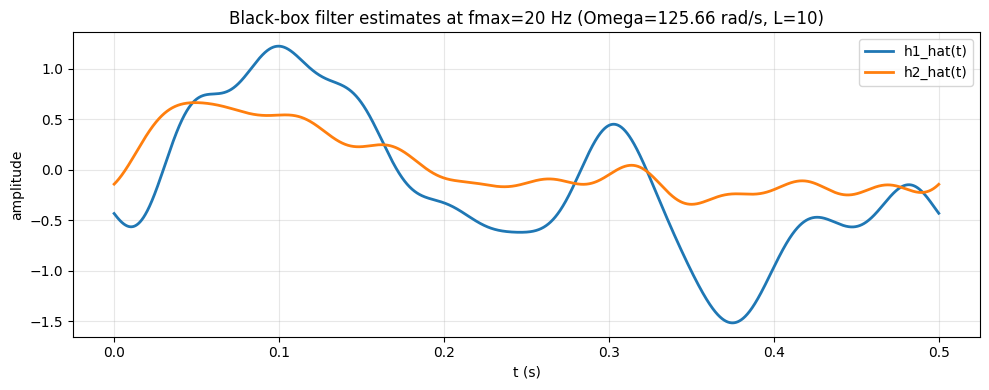

[i=02] fmax=30.0Hz | Omega=  188.50 rad/s | L=15 | unknowns/filter=31
  [h1] rows=248 rank=31/31 cond≈3.89e+00 rel_resid=7.76e-01 M=5.0e-03
  [h2] rows=256 rank=31/31 cond≈3.40e+00 rel_resid=6.90e-01 M=5.0e-03
  epsilon_i = 3.230e-01


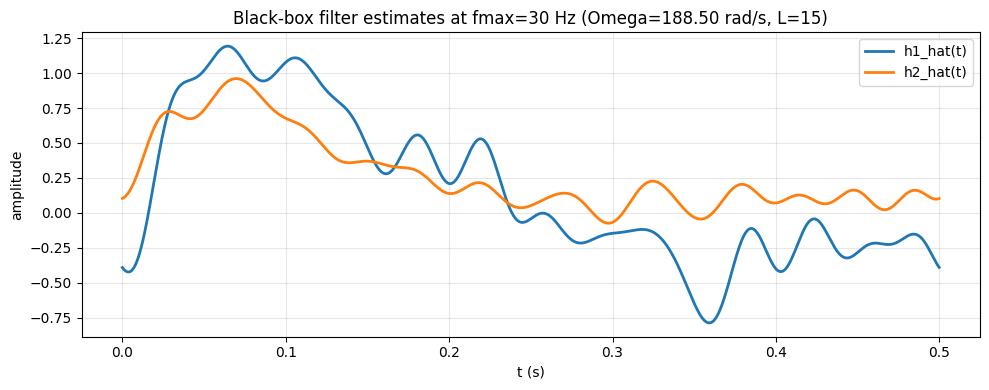

[i=03] fmax=40.0Hz | Omega=  251.33 rad/s | L=20 | unknowns/filter=41
  [h1] rows=339 rank=41/41 cond≈3.02e+00 rel_resid=7.65e-01 M=5.0e-03
  [h2] rows=337 rank=41/41 cond≈3.16e+00 rel_resid=6.75e-01 M=5.0e-03
  epsilon_i = 9.329e-02


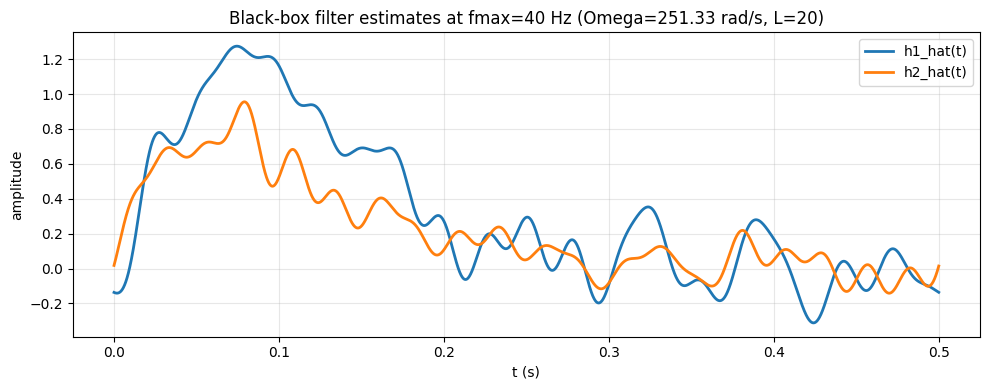

[i=04] fmax=50.0Hz | Omega=  314.16 rad/s | L=25 | unknowns/filter=51
  [h1] rows=410 rank=51/51 cond≈3.13e+00 rel_resid=7.55e-01 M=5.0e-03
  [h2] rows=411 rank=51/51 cond≈3.01e+00 rel_resid=6.02e-01 M=5.0e-03
  epsilon_i = 2.806e-02


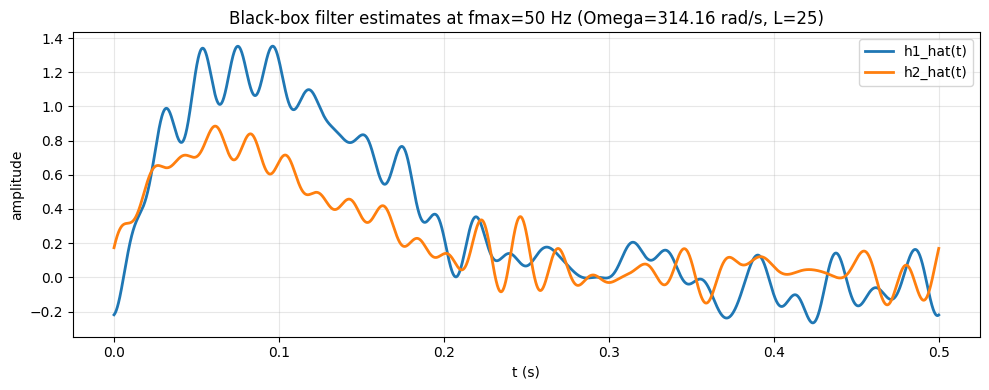

[i=05] fmax=60.0Hz | Omega=  376.99 rad/s | L=30 | unknowns/filter=61
  [h1] rows=492 rank=61/61 cond≈3.15e+00 rel_resid=6.94e-01 M=5.0e-03
  [h2] rows=497 rank=61/61 cond≈2.97e+00 rel_resid=5.21e-01 M=5.0e-03
  epsilon_i = 3.940e-02


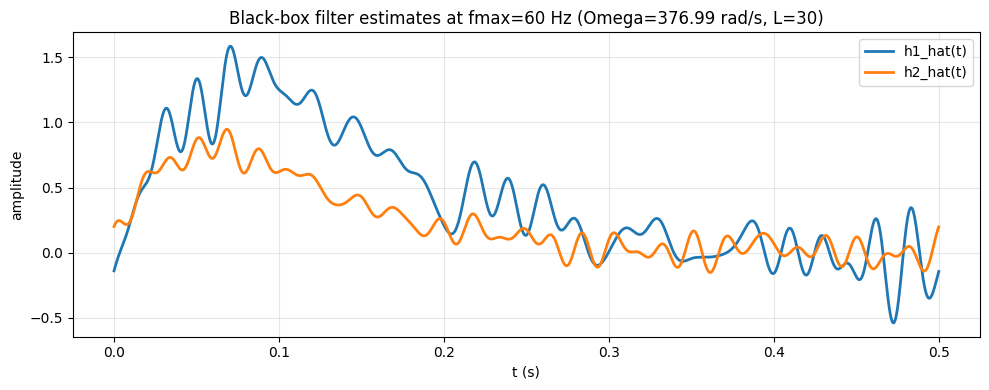

[i=06] fmax=70.0Hz | Omega=  439.82 rad/s | L=35 | unknowns/filter=71
  [h1] rows=570 rank=71/71 cond≈2.81e+00 rel_resid=6.69e-01 M=5.0e-03
  [h2] rows=570 rank=71/71 cond≈3.19e+00 rel_resid=7.04e-01 M=1.0e-02
  epsilon_i = 3.420e-02


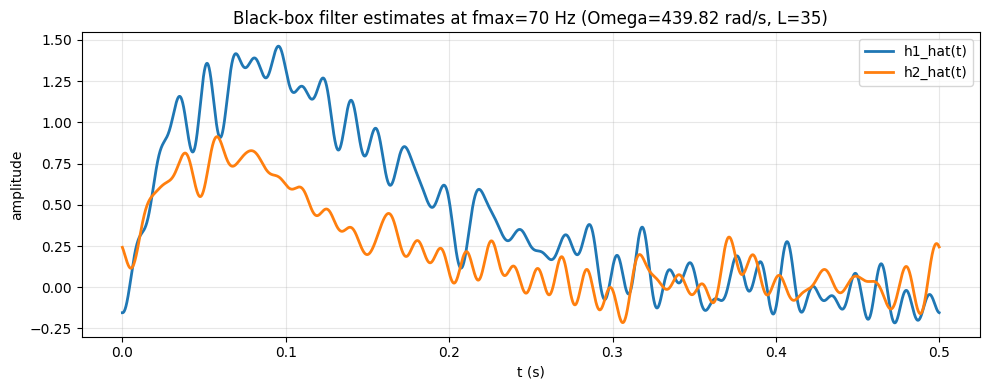

[i=07] fmax=80.0Hz | Omega=  502.65 rad/s | L=40 | unknowns/filter=81
  [h1] rows=651 rank=81/81 cond≈2.76e+00 rel_resid=6.18e-01 M=5.0e-03
  [h2] rows=661 rank=81/81 cond≈2.74e+00 rel_resid=6.22e-01 M=1.0e-02
  epsilon_i = 3.138e-02


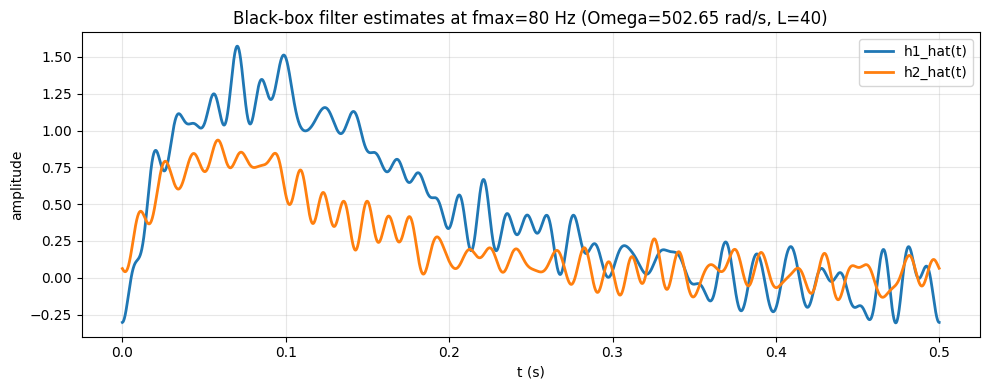

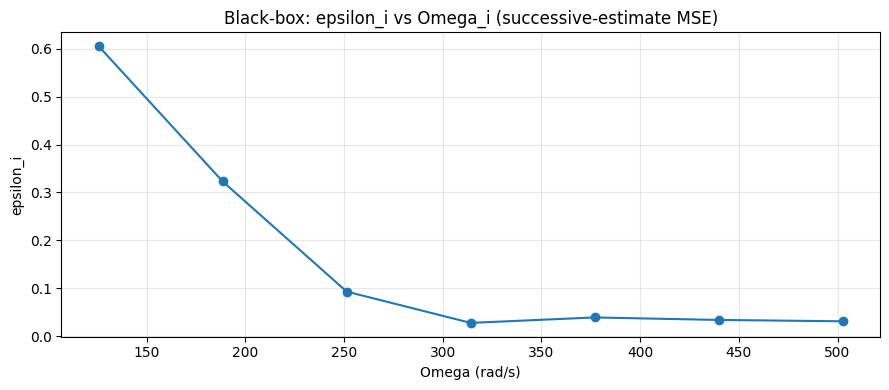

In [34]:
# this single code cell is where part 2 of problem 2 will be completed (2.1 + 2.2)
# the BLACK-BOX single cell
# will use the same identification equations that we just saw in the white-box:

#it is worth noting that there are some significant measures taken to reduce the
#runtime, including :
#   -   a nested stimuli across bandwidths (generate at Lmax, truncate)
#   -  a more short amplitude ladder, deterministic, with early exit
#   -  a reduced K_cap

#if you want to see a better plot with reduced rel_resid values, just do the following:
# increase the K_cap (for exampleback to 6000 again) while keeping nested stimuli and the fixed M ladder
# increase the row_factor to 10
# Both improve fit stability but increase runtime.

import numpy as np
import matplotlib.pyplot as plt
import importlib.util, sys
model_file = "/content/drive/MyDrive/CCircuits/project2/model_aes2376.py"
spec = importlib.util.spec_from_file_location("model_aes2376", model_file)
bb = importlib.util.module_from_spec(spec)
sys.modules["model_aes2376"] = bb
spec.loader.exec_module(bb)
print("Loaded from:", bb.__file__)

dt = 1e-5
df = 2.0
T  = 1.0 / df              #0.5 s
t  = np.arange(0.0, T, dt)
delta = 5e-5

# the bandwidths we;re choosing to sweep
fmax_list = [20, 30, 40, 50, 60, 70, 80]
Omega_list = [2.0 * np.pi * f for f in fmax_list]
L_list = [int(round(fmax / df)) for fmax in fmax_list]
Lmax = max(L_list)

# controls that again reduce runtime and increase the rel_resid values:
row_factor = 8.0          # keep at 8 # or 8.0
K_cap = 6000              # reduced from 6000 # reduced output: 3000
n_trials_max = 80         # go back to 80 for more clear output # reduced to 35.
rcond = 1e-12

# this is the short amplitude ladder deterministic
# and this is where most of the runtime gains are going to come from.
M_ladder = (5e-3, 1e-2, 2e-2)

plot_ds = 10 # this is for plotting downsample.

# different utilities
def random_trig_coeffs(L: int, rng: np.random.Generator):
    u_l = np.zeros(2 * L + 1, dtype=np.complex128)
    u_l[L] = rng.normal(0.0, 1.0)
    pos = rng.normal(0.0, 1.0, size=L) + 1j * rng.normal(0.0, 1.0, size=L)
    u_l[L + 1 :] = pos
    u_l[:L] = np.conj(pos[::-1])
    return u_l

def synth_from_coeffs(u_l: np.ndarray, t: np.ndarray, df: float):
    L = (len(u_l) - 1) // 2
    l_grid = np.arange(-L, L + 1)
    E = np.exp(1j * 2.0 * np.pi * (l_grid[None, :] * df) * t[:, None])
    return np.real(E @ u_l)

def normalize_coeffs_and_signal(u_l: np.ndarray, t: np.ndarray, df: float):
    u = synth_from_coeffs(u_l, t, df)
    m = np.max(np.abs(u))
    if m > 0:
        return u_l / m, u / m
    return u_l, u

def aer_q_from_tk(tk: np.ndarray, delta: float):
    return delta * np.cumsum(np.sign(tk))

# nested N base stimulu
def truncate_coeffs(u_l_max: np.ndarray, Lmax: int, L: int):
    # the u_l_max is ordered -Lmax..Lmax, so just take centered slice for -L..L
    start = (Lmax - L)
    end = (Lmax + L) + 1
    return u_l_max[start:end]

# just pre-generate base coeffs (since they are reused across all Ω)
rng_base = np.random.default_rng(0)
base_coeffs = []
for tr in range(n_trials_max):
    u_l0 = random_trig_coeffs(Lmax, rng_base)
    u_l0, _ = normalize_coeffs_and_signal(u_l0, t, df)
    base_coeffs.append(u_l0)
base_coeffs = np.array(base_coeffs)  # (n_trials_max, 2*Lmax+1)

# this is to
#Estimate the one channel at a given L using the exact same Φ,q model
# the channel_idx: 0 for h1, 1 for h2
def estimate_filter_one_channel(channel_idx: int, L: int, fmax: float):
    unknowns = 2 * L + 1
    target_rows = int(np.ceil(row_factor * unknowns))
    target_rows = min(target_rows, K_cap)

    l_grid = np.arange(-L, L + 1)

    # smaller aplictude latter to reduce runtime.
    last_debug = None
    for M in M_ladder:
        Phi_blocks = []
        q_blocks = []
        rows_used = 0
        trials_used = 0

        for tr in range(n_trials_max):
            u_l = truncate_coeffs(base_coeffs[tr], Lmax, L)
            u_l, u = normalize_coeffs_and_signal(u_l, t, df)  # normalize
            u_l = M * u_l
            u = M * u

            U = np.zeros((2, len(t)), dtype=float)
            U[channel_idx] = u

            tk = np.array(bb.model(t, U, "Dendrite"), dtype=float)
            tk = tk[(np.abs(tk) >= 0.0) & (np.abs(tk) < T)]
            if tk.size < 2:
                continue

            q = aer_q_from_tk(tk, delta)

            tk_abs = np.abs(tk)
            E = np.exp(1j * 2.0 * np.pi * (tk_abs[:, None] * (l_grid[None, :] * df)))
            Phi = (u_l[None, :] * E)

            # cap the rows
            if rows_used + Phi.shape[0] > K_cap:
                take = K_cap - rows_used
                if take > 0:
                    Phi_blocks.append(Phi[:take])
                    q_blocks.append(q[:take])
                    rows_used += take
                break
            else:
                Phi_blocks.append(Phi)
                q_blocks.append(q)
                rows_used += Phi.shape[0]

            trials_used += 1
            if rows_used >= target_rows:
                break

        last_debug = (M, rows_used, trials_used, unknowns, target_rows)

        if rows_used >= max(unknowns, target_rows):
            Phi_all = np.vstack(Phi_blocks)
            q_all = np.concatenate(q_blocks)

            h_hat_l, residuals, rank, svals = np.linalg.lstsq(Phi_all, q_all, rcond=rcond)
            h_hat_t = synth_from_coeffs(h_hat_l, t, df)

            info = {
                "L": L,
                "unknowns": unknowns,
                "target_rows": target_rows,
                "rows_used": int(Phi_all.shape[0]),
                "trials_used": int(trials_used),
                "M_used": float(M),
                "rank": int(rank),
                "cond_approx": float(svals[0] / svals[-1]) if len(svals) > 1 and svals[-1] > 0 else np.inf,
                "rel_resid": float(np.linalg.norm(Phi_all @ h_hat_l - q_all) / (np.linalg.norm(q_all) + 1e-15)),
            }
            return h_hat_t, h_hat_l, info

    # If we fail all M, raise with useful debug
    M, rows_used, trials_used, unknowns, target_rows = last_debug
    raise RuntimeError(
        f"Channel {channel_idx} at fmax={fmax}Hz (L={L}): insufficient equations. "
        f"Last try: M={M}, rows_used={rows_used}, unknowns={unknowns}, target_rows={target_rows}, trials_used={trials_used}. "
        f"Increase n_trials_max, K_cap, or extend M_ladder."
    )

# -------------------------
# Sweep: estimate h1,h2 for each bandwidth; compute epsilon_i; plot filters per bandwidth
# -------------------------
eps_list = []
h1_prev = None
h2_prev = None

print("\n BLACK-BOX Neuron indentification START")
print(f"[setup] dt={dt:.1e}  T={T:.3f}s  df={df:.1f}Hz  delta={delta:.1e}")
print(f"[id]   row_factor={row_factor}  n_trials_max={n_trials_max}  K_cap={K_cap}  M_ladder={M_ladder}")

for i, fmax in enumerate(fmax_list, start=1):
    Omega = 2.0 * np.pi * fmax
    L = int(round(fmax / df))

    h1_t, h1_l, info1 = estimate_filter_one_channel(channel_idx=0, L=L, fmax=fmax)
    h2_t, h2_l, info2 = estimate_filter_one_channel(channel_idx=1, L=L, fmax=fmax)

    if h1_prev is None:
        eps_i = np.mean(h1_t**2) + np.mean(h2_t**2)
    else:
        eps_i = np.mean((h1_t - h1_prev)**2) + np.mean((h2_t - h2_prev)**2)

    eps_list.append(float(eps_i))
    h1_prev, h2_prev = h1_t, h2_t

    print(f"[i={i:02d}] fmax={fmax:>4.1f}Hz | Omega={Omega:>8.2f} rad/s | L={L:>2d} | unknowns/filter={2*L+1}")
    print(f"  [h1] rows={info1['rows_used']} rank={info1['rank']}/{info1['unknowns']} cond≈{info1['cond_approx']:.2e} rel_resid={info1['rel_resid']:.2e} M={info1['M_used']:.1e}")
    print(f"  [h2] rows={info2['rows_used']} rank={info2['rank']}/{info2['unknowns']} cond≈{info2['cond_approx']:.2e} rel_resid={info2['rel_resid']:.2e} M={info2['M_used']:.1e}")
    print(f"  epsilon_i = {eps_i:.3e}")

    # Plot both of the filters for this bandwidth on the same axes on same plot
    plt.figure(figsize=(10, 4))
    plt.plot(t[::plot_ds], h1_t[::plot_ds], linewidth=2, label="h1_hat(t)")
    plt.plot(t[::plot_ds], h2_t[::plot_ds], linewidth=2, label="h2_hat(t)")
    plt.xlabel("t (s)")
    plt.ylabel("amplitude")
    plt.title(f"Black-box filter estimates at fmax={fmax} Hz (Omega={Omega:.2f} rad/s, L={L})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# make sure to plot the epsilon as well,
plt.figure(figsize=(9, 4))
plt.plot(Omega_list, eps_list, marker="o")
plt.xlabel("Omega (rad/s)")
plt.ylabel("epsilon_i")
plt.title("Black-box: epsilon_i vs Omega_i (successive-estimate MSE)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


To provide a little commentary on our answer to **Part 2.2**, we essentially just repeated the same filter-identification experiment many times while also gradually increasing the input bandwidth $(\Omega_i)$ (equivalently, increasing $f_{\max}$, where $\Omega_i = 2\pi f_{\max}$). For each of the bandwidth settings $i$, we then generated some random nonzero bandlimited inputs $\mathbf{u} = (u_1, u_2)$ in the trigonometric-polynomial space while also making use of a fixed frequency spacing $df = 2\,\text{Hz}$, so that the period is going to end up being fixed at

$$
T = \frac{1}{df} = 0.5\,\text{s},
$$

and then we’re going to estimate filters over $t \in [0, 0.5]$.

We identified that the two dendritic filters are separated by exciting one channel at a time, meaning that to estimate $h_1$ we had to use inputs of the form $(u, 0)$, and in order to estimate $h_2$ we had to use $(0, u)$. Accordingly, the black-box neuron returned signed ON/OFF spike times, and we then converted those signed spikes into a measurement vector using the previously mentioned AER rule.

$$
q_k = \delta \cdot \sum_{m \le k} \mathrm{sgn}(t_m),
$$

with the now verified threshold $\delta = 5 \times 10^{-5}$. We are able to build the corresponding observation matrix $\Phi$ from the same trigonometric basis evaluated at $|t_k|$, and then solve a linear system in order to recover $\hat{h}_{1,i}(t)$ and $\hat{h}_{2,i}(t)$ at each of our bandwidths.

Then, in order to quantify how much the estimates are going to change as the varied bandwidth increases, we computed the successive-estimate mean-square error outlined in the problem description.

$$
\epsilon_i
=
\mathrm{MSE}\!\left(\hat{h}_{1,i-1}, \hat{h}_{1,i}\right)
+
\mathrm{MSE}\!\left(\hat{h}_{2,i-1}, \hat{h}_{2,i}\right),
\qquad
\text{with } \hat{h}_{1,0} = \hat{h}_{2,0} = 0.
$$

Additionally, we also then plotted $\epsilon_i$ versus $\Omega_i$. What we ended up finding was that there was a clear “drop then plateau” pattern: at low bandwidth, we see that the estimates change a lot from one bandwidth to the next (large $\epsilon_i$), but once the bandwidth is high enough, the estimates stop changing much (small $\epsilon_i$ that stays small).

Numerically, $\epsilon_i$ was large at $f_{\max} = 20\,\text{Hz}$ ($\Omega \approx 126\,\text{rad/s}$, $\epsilon \approx 0.605$) and was also still sizable at $30\,\text{Hz}$ ($\Omega \approx 189\,\text{rad/s}$, $\epsilon \approx 0.323$). It then dropped strongly by $40\,\text{Hz}$ ($\Omega \approx 251\,\text{rad/s}$, $\epsilon \approx 0.093$). After $50\,\text{Hz}$ ($\Omega \approx 314\,\text{rad/s}$), $\epsilon_i$ stayed low and remained relatively flat across all of the higher bandwidths (about $0.03$ to $0.05$ from $50$ through $80\,\text{Hz}$).

All in all, we would say that this means once we let the input signal include frequency content up to about $50\,\text{Hz}$, giving the neuron even higher-frequency inputs does not materially change the recovered filters, meaning that we are no longer “learning any sort of new structure” in $h_1(t)$ and $h_2(t)$. Therefore, based on the plateau in the $\epsilon_i$ versus $\Omega_i$ plot, we are going to find that the effective bandwidth of the unknown dendritic processing filters is approximately

$$
f_{\mathrm{eff}} \approx 50\,\text{Hz},
\qquad
\Omega_{\mathrm{eff}} \approx 2\pi \cdot 50 \approx 314\,\text{rad/s}.
$$





# **Bonus**

(12.5 points) In HW5-Q2, you worked out the theory to estimate the filters $h_1, h_2$ _separately_, which you can use in Part 2 of this question. For this bonus question, write down the theory and simulate your results for _jointly_ estimating $h_1, h_2$ using two sets of randomly generated stimuli ${\bf u^1}$ and ${\bf u^2}$ wherein all the signals $u_1^1, u_2^1, u_1^2, u_2^2$ are _non-zero_.  


This is the theory component of the bonus question, the joint identification of h1 and h2 using two 2-channel experiments (where all of the inputs are going to be non-zero)

### 1) System model (what are we identifying)
In the dendrite mode, we know that the black-box neuron first applies two unknown linear time-invariant (LTI) dendritic filters $h_1(t)$, $h_2(t)$ to the two input currents $u_1(t)$, $u_2(t)$, then it will summ them up in order to form the soma (axon hillock( current:

$$
v(t) = (u_1 * h_1)(t) + (u_2 * h_2)(t),
$$

where $*$ denotes the idea of convolution. Our goal is going to be to estimate $h_1$ and $h_2$ on the order of $t \in [0, 0.5]$ seconds.

### 2) The second step is to restrict to the trigonometric-polynomial space (finite-dimensional unknowns)
As was done in HW5-Q2 (and in Project 2), we are going to first choose inputs that lie in a trigonometric-polynomial space with a frequency line spacing $df$, so that the period is going to be $T = 1/df$ (here $T = 0.5$ s when $df = 2$ Hz). For a chosen bandwidth $f_{\max}$, we will define $L$ so that $L\,df \approx f_{\max}$. Then we will represent those inputs as:

$$
u_1(t) = \sum_{l=-L}^{L} u_{1,l}\,\exp\!\big(j\,2\pi (l\,df)\,t\big),
$$

$$
u_2(t) = \sum_{l=-L}^{L} u_{2,l}\,\exp\!\big(j\,2\pi (l\,df)\,t\big),
$$

and similarly represent each of the unknown filters as:

$$
h_1(t) = \sum_{l=-L}^{L} h_{1,l}\,\exp\!\big(j\,2\pi (l\,df)\,t\big),
$$

$$
h_2(t) = \sum_{l=-L}^{L} h_{2,l}\,\exp\!\big(j\,2\pi (l\,df)\,t\big).
$$

this is going to reduce identification to estimating the finite set of coefficients $\{h_{1,l}\}$ and $\{h_{2,l}\}$ ($2L+1$ coefficients per filter).

### 3) In the third step, convolution becomes multiplication in the domain of the coefficient
In this representation, the convolution of the two trigonometric-polynomial signals is going to corresponds to coefficient-wise multiplication. Therefore, we will find that the soma input $v(t)$ has the coefficient representation:

$$
v(t) = \sum_{l=-L}^{L} \big(u_{1,l}\,h_{1,l} + u_{2,l}\,h_{2,l}\big)\,\exp\!\big(j\,2\pi (l\,df)\,t\big).
$$

So $v(t)$ is going to be depending linearly on the unknown coefficient vectors $h_1 = [h_{1,-L},\ldots,h_{1,L}]^T$ and $h_2 = [h_{2,-L},\ldots,h_{2,L}]^T$.

### 4) The AER ON/OFF encoding is going to give linear measurements at different spike times
We find that the axon-hillock is an ON/OFF AER encoder with threshold $\delta$. to this end, it emits signed spike times $t_k$, where the ON spikes have positive sign and the OFF spikes are stored with a negative sign. The AER "t-transform" (Found in chapter 8: AER neuron with thresholding and feedback) then converts the signed spike train into a measurement vector:

$$
q_k = \delta \sum_{m=1}^{k} \operatorname{sgn}(t_m),
$$

where $\operatorname{sgn}(t_m) = +1$ for ON spikes and = $-1$ for OFF spikes.

A key property from the AER theory is that each of the spike times provides a linear constraint relating $v(t)$ evaluated through the trig basis to $q_k$. concretely, this means by expanding $v$ at the spike time magnitude $|t_k|$ gives:

$$
\sum_{l=-L}^{L} \big(u_{1,l}\,h_{1,l} + u_{2,l}\,h_{2,l}\big)\,\exp\!\big(j\,2\pi (l\,df)\,|t_k|\big) = q_k.
$$

This is linear in the unknowns $h_{1,l}$ and $h_{2,l}$.

### 5) Now we are going to write one experiment as a single linear system in this joint unknown vector
The next step is to define the joint unknown vector by concatenating both of the filters’ coefficients:

$$
h = \big[\, h_{1,-L}\ \ldots\ h_{1,L}\ \ \ h_{2,-L}\ \ldots\ h_{2,L}\,\big]^T,
$$

which has dimensions $2(2L+1)$.

For a single 2-channel experiment $(u_1,u_2)$ that produces spikes $\{t_k\}$, we are going to be able to define the row of the observation matrix for spike $k$ as:

$$
\Phi_k =
\Big[
u_{1,l}\,\exp\!\big(j\,2\pi(l\,df)\,|t_k|\big)\ \text{for } l=-L,\ldots,L,\ \
u_{2,l}\,\exp\!\big(j\,2\pi(l\,df)\,|t_k|\big)\ \text{for } l=-L,\ldots,L
\Big].
$$

Then, stacking these rows for all spikes in the experiment gives us the matrix $\Phi$ and the vector $q$ such that:

$$
\Phi\,h = q.
$$

This is going to be the "joint" identification equation. We see that $h_1$ and $h_2$ are solved simultaneously in one system, instead of isolating the channels.

### 6) Why the bonus requires TWO different 2D stimuli with all of the inputs having to be non-zero
If we only run one 2D experiment, it is possible for $\Phi$ to be poorly conditioned or not fully informative about both of the filters, because the contributions from $u_1$ and $u_2$ can be correlated in a way that ends up making $h_1$ and $h_2$ very hard to separate. this means that the bonus is therefore going to ask for two independent input pairs:

$$
u^{(1)}(t) = \big(u_1^{(1)}(t), u_2^{(1)}(t)\big),
\qquad
u^{(2)}(t) = \big(u_1^{(2)}(t), u_2^{(2)}(t)\big),
$$

with all of the four signals $u_1^{(1)}$, $u_2^{(1)}$, $u_1^{(2)}$, $u_2^{(2)}$ being non-zero.

Each of the experiments is going to produce its own spike times and hence its own system:

$$
\Phi^{(1)} h = q^{(1)}, \qquad \Phi^{(2)} h = q^{(2)}.
$$

We then are going to stack them to get a larger system, which looks like:

$$
\begin{bmatrix}
\Phi^{(1)} \\
\Phi^{(2)}
\end{bmatrix}
h
=
\begin{bmatrix}
q^{(1)} \\
q^{(2)}
\end{bmatrix}.
$$

this is increases the number of equations and, also very importantly, leads to an increase in the identifiability because the second input pair provides a different mixing of $h_1$ and $h_2$.

### 7) The final estimator (least squares)
With enough of the spikes (rows) so that the stacked $\Phi$ has full column rank (or at least is well-conditioned), we are able to estimate $h$ by least squares:

$$
\hat{h} = \arg\min_{h} \|\Phi h - q\|_2^2,
$$

which can then be computed by `np.linalg.lstsq` or at least a pseudoinverse.

Finally, we are going to split $\hat{h}$ back into $\hat{h}_{1,l}$ and $\hat{h}_{2,l}$ and then reconstruct $\hat{h}_1(t)$, $\hat{h}_2(t)$ in time using the trig basis on $t \in [0,0.5]$.

Loaded from: /content/drive/MyDrive/CCircuits/project2/model_aes2376.py

 the bonus: JOINT (h1,h2) ESTIMATION 
[setup] fmax=50.0 Hz  Omega=314.16 rad/s  df=2.0 Hz  T=0.5 s  L=25  unknowns=102
[solve] M_used=5.00e-03  rows_used=1048  trials_used=27
[solve] rank=102/102  cond≈2.63e+00  rel_resid=6.28e-01


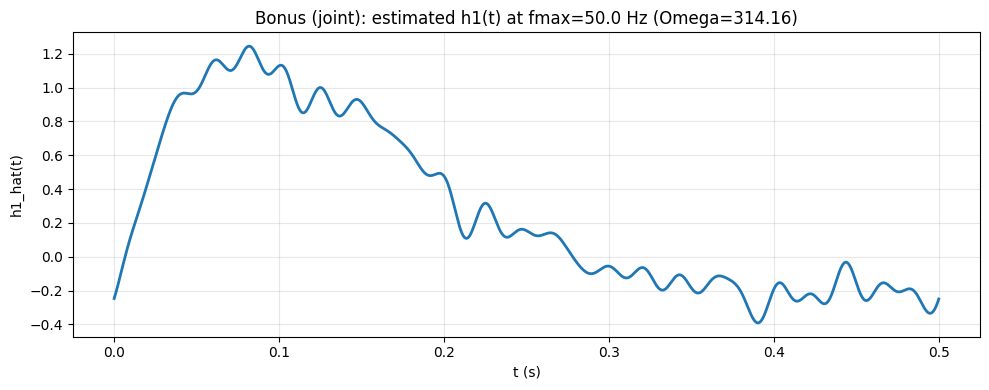

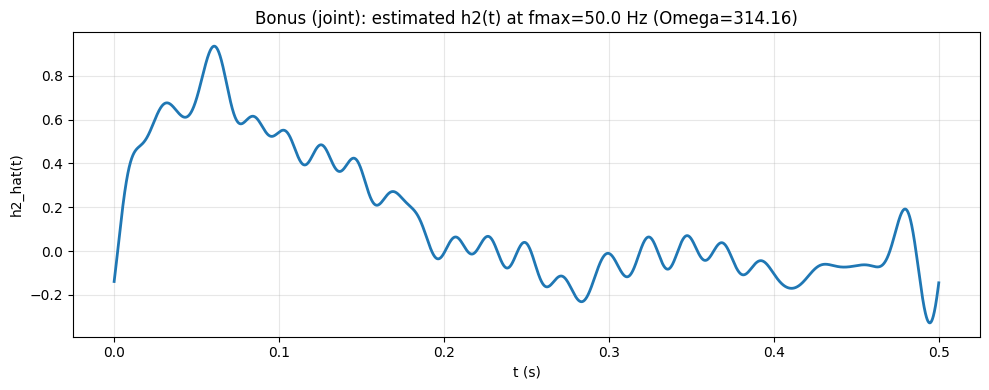

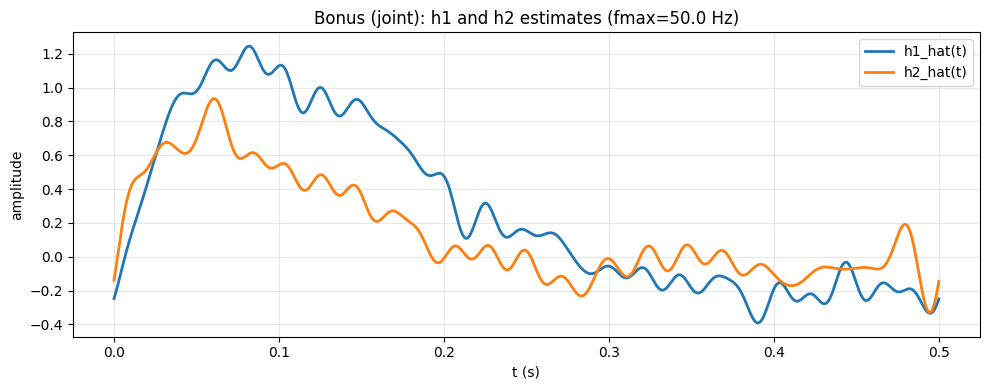

In [35]:
# this is the computational code cell component of the bonus question.
# where we  are going to jointly estimate h1,h2 using TWO 2-channel experiments
# this is also going to be using the same signed-spike AER q construction as in Problem 2.

import numpy as np
import matplotlib.pyplot as plt
import importlib.util, sys
model_file = "/content/drive/MyDrive/CCircuits/project2/model_aes2376.py"
spec = importlib.util.spec_from_file_location("model_aes2376", model_file)
bb = importlib.util.module_from_spec(spec)
sys.modules["model_aes2376"] = bb
spec.loader.exec_module(bb)
print("Loaded from:", bb.__file__)
#same
dt = 1e-5
df = 2.0
T  = 1.0 / df #0.5 s
t  = np.arange(0.0, T, dt)
delta = 5e-5 # verified in 2.1

# This section is just meant to choose the bandwidth for the estimate.
# I believe that using the effective-bandwidth region is reasonable.
fmax = 50.0
Omega = 2.0 * np.pi * fmax
L = int(round(fmax / df)) #so L*df ≈ fmax
l_grid = np.arange(-L, L + 1)

# these are the identification controls
unknowns_total = 2 * (2 * L + 1)   # for h1_l and h2_l
row_factor = 10.0                  # these are the target rows ~= row_factor * unknowns_total
target_rows = int(np.ceil(row_factor * unknowns_total))
K_cap = 12000                      # in order to cap rows for speed
n_trials_max = 120                 # this is the # of random trials
M_ladder = (5e-3, 1e-2, 2e-2, 5e-2) # the amplitude ladder in order to ensure enough spikes
rcond = 1e-12

# the trig poly  utilities.
def random_trig_coeffs(L: int, rng: np.random.Generator):
    u_l = np.zeros(2 * L + 1, dtype=np.complex128)
    u_l[L] = rng.normal(0.0, 1.0)  # the dc real
    pos = rng.normal(0.0, 1.0, size=L) + 1j * rng.normal(0.0, 1.0, size=L)
    u_l[L + 1 :] = pos
    u_l[:L] = np.conj(pos[::-1])
    return u_l

def synth_from_coeffs(c_l: np.ndarray, t: np.ndarray, df: float):
    Lloc = (len(c_l) - 1) // 2
    lloc = np.arange(-Lloc, Lloc + 1)
    E = np.exp(1j * 2.0 * np.pi * (lloc[None, :] * df) * t[:, None])
    return np.real(E @ c_l)

def normalize_coeffs_and_signal(u_l: np.ndarray, t: np.ndarray, df: float):
    u = synth_from_coeffs(u_l, t, df)
    m = np.max(np.abs(u))
    if m > 0:
        return u_l / m, u / m
    return u_l, u

def aer_q_from_tk(tk: np.ndarray, delta: float):
    return delta * np.cumsum(np.sign(tk))

# this block is going to build the Φ,q from ONE 2-channel experiment
# we get the equation per a specifc spike of ours:
# this should be the eqn (u1_l * exp(j2π l df |tk|))·h1_l + (u2_l * exp(j2π l df |tk|))·h2_l = q
def build_Phi_q_for_experiment(u1_l, u2_l, U_time):
    tk = np.array(bb.model(t, U_time, "Dendrite"), dtype=float)
    # keep spikes within [0,T)
    tk = tk[(np.abs(tk) >= 0.0) & (np.abs(tk) < T)]
    if tk.size < 2:
        return None, None, 0

    q = aer_q_from_tk(tk, delta)  # this basicaly just uses the diff signed spikes

    tk_abs = np.abs(tk)
    E = np.exp(1j * 2.0 * np.pi * (tk_abs[:, None] * (l_grid[None, :] * df))) # (K,2L+1)

    Phi1 = u1_l[None, :] * E
    Phi2 = u2_l[None, :] * E
    Phi = np.hstack([Phi1, Phi2]) #(K, 2*(2L+1))

    return Phi, q, tk.size

# This part is going to be the joint estimation that is using TWO experiments per trial:
#  we see that experiment 1 is going to use (u1^1,u2^1) both of which are non-zero
#and then experiment 2 is going to be using (u1^2,u2^2) non-zero
# so lets just stack all of the spike equations
#from both experiments (and across trials) then solve LS.

rng = np.random.default_rng(0)

best = None
for M in M_ladder:
    Phi_blocks = []
    q_blocks = []
    rows_used = 0
    spikes_total = 0
    trials_used = 0

    for tr in range(n_trials_max):
        # this is experiment 1
        u11_l = random_trig_coeffs(L, rng)
        u12_l = random_trig_coeffs(L, rng)
        u11_l, u11 = normalize_coeffs_and_signal(u11_l, t, df)
        u12_l, u12 = normalize_coeffs_and_signal(u12_l, t, df)

        #experiment 2
        u21_l = random_trig_coeffs(L, rng)
        u22_l = random_trig_coeffs(L, rng)
        u21_l, u21 = normalize_coeffs_and_signal(u21_l, t, df)
        u22_l, u22 = normalize_coeffs_and_signal(u22_l, t, df)

        # this should hopefully enforce the non-zero signals
        if np.max(np.abs(u11)) == 0 or np.max(np.abs(u12)) == 0 or np.max(np.abs(u21)) == 0 or np.max(np.abs(u22)) == 0:
            continue

        # and lets apply amplitude M (to keep both channels non-zero)
        u11_l, u11 = M * u11_l, M * u11
        u12_l, u12 = M * u12_l, M * u12
        u21_l, u21 = M * u21_l, M * u21
        u22_l, u22 = M * u22_l, M * u22
        U1 = np.vstack([u11, u12])
        U2 = np.vstack([u21, u22])

        Phi1, q1, K1 = build_Phi_q_for_experiment(u11_l, u12_l, U1)
        Phi2, q2, K2 = build_Phi_q_for_experiment(u21_l, u22_l, U2)

        if Phi1 is None or Phi2 is None:
            continue

        # this will stack the two experiments for this trial.
        Phi_trial = np.vstack([Phi1, Phi2])
        q_trial = np.concatenate([q1, q2])

        # and if we could also cap the rows so it doesn't blow up.
        if rows_used + Phi_trial.shape[0] > K_cap:
            take = K_cap - rows_used
            if take > 0:
                Phi_blocks.append(Phi_trial[:take])
                q_blocks.append(q_trial[:take])
                rows_used += take
            break
        else:
            Phi_blocks.append(Phi_trial)
            q_blocks.append(q_trial)
            rows_used += Phi_trial.shape[0]
            spikes_total += (K1 + K2)

        trials_used += 1
        if rows_used >= min(target_rows, K_cap):
            break

    if rows_used >= max(unknowns_total, min(target_rows, K_cap)):
        Phi_all = np.vstack(Phi_blocks)
        q_all = np.concatenate(q_blocks)

        h_hat, residuals, rank, svals = np.linalg.lstsq(Phi_all, q_all, rcond=rcond)
        cond_approx = float(svals[0] / svals[-1]) if len(svals) > 1 and svals[-1] > 0 else np.inf
        rel_resid = float(np.linalg.norm(Phi_all @ h_hat - q_all) / (np.linalg.norm(q_all) + 1e-15))

        h1_hat_l = h_hat[: (2 * L + 1)]
        h2_hat_l = h_hat[(2 * L + 1) :]

        h1_hat_t = synth_from_coeffs(h1_hat_l, t, df)
        h2_hat_t = synth_from_coeffs(h2_hat_l, t, df)

        best = {
            "M": M,
            "rows_used": int(Phi_all.shape[0]),
            "trials_used": int(trials_used),
            "rank": int(rank),
            "cond_approx": cond_approx,
            "rel_resid": rel_resid,
            "h1_hat_t": h1_hat_t,
            "h2_hat_t": h2_hat_t,
        }
        break

if best is None:
    raise RuntimeError(
        "Joint estimation failed to gather enough equations. "
        "Increase n_trials_max, K_cap, or extend M_ladder upward."
    )

print("\n the bonus: JOINT (h1,h2) ESTIMATION ")
print(f"[setup] fmax={fmax} Hz  Omega={Omega:.2f} rad/s  df={df} Hz  T={T} s  L={L}  unknowns={unknowns_total}")
print(f"[solve] M_used={best['M']:.2e}  rows_used={best['rows_used']}  trials_used={best['trials_used']}")
print(f"[solve] rank={best['rank']}/{unknowns_total}  cond≈{best['cond_approx']:.2e}  rel_resid={best['rel_resid']:.2e}")

#plots
ds = 10  # just downsample for the plotting only

plt.figure(figsize=(10, 4))
plt.plot(t[::ds], best["h1_hat_t"][::ds], linewidth=2)
plt.xlabel("t (s)")
plt.ylabel("h1_hat(t)")
plt.title(f"Bonus (joint): estimated h1(t) at fmax={fmax} Hz (Omega={Omega:.2f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t[::ds], best["h2_hat_t"][::ds], linewidth=2)
plt.xlabel("t (s)")
plt.ylabel("h2_hat(t)")
plt.title(f"Bonus (joint): estimated h2(t) at fmax={fmax} Hz (Omega={Omega:.2f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# put then both on one plot.
plt.figure(figsize=(10, 4))
plt.plot(t[::ds], best["h1_hat_t"][::ds], linewidth=2, label="h1_hat(t)")
plt.plot(t[::ds], best["h2_hat_t"][::ds], linewidth=2, label="h2_hat(t)")
plt.xlabel("t (s)")
plt.ylabel("amplitude")
plt.title(f"Bonus (joint): h1 and h2 estimates (fmax={fmax} Hz)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
